# `markov_regimes` — Module Reference

The `markov_regimes` package implements a Markov regime-switching scenario generator. It combines independent discrete-time Markov chains (governing regime states) with vector Ornstein-Uhlenbeck dynamics (governing continuous process values).

The package exposes three classes:

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

from markov_regimes import RegimeConfig, ProcessConfig, ScenarioModel

---

## `config.py` — `RegimeConfig`

A dataclass holding the OU parameter triple for a single regime.

| Field   | Type         | Description |
|---------|--------------|-------------|
| `K`     | `np.ndarray` | Mean-reversion matrix, shape $(d \times d)$. Half-life: $t_{1/2} = \ln(2) / K$. |
| `mu`    | `np.ndarray` | Long-run mean vector, shape $(d,)$. |
| `sigma` | `np.ndarray` | Volatility matrix, shape $(d \times d)$. Set to zero for deterministic processes. |

All fields are cast to `float64` on construction. Plain Python lists are accepted.

**Methods:** `validate(d)` checks that K, mu, sigma have shapes consistent with dimension `d`.

In [2]:
import numpy as np

# Construct from lists — auto-converted to float64 arrays
rc = RegimeConfig(K=[[0.5]], mu=[3.0], sigma=[[0.1]])
print(f"K dtype: {rc.K.dtype}, mu shape: {rc.mu.shape}, sigma shape: {rc.sigma.shape}")

# Validation passes for d=1
rc.validate(1)
print("validate(1) passed")

# Validation fails for wrong dimension
try:
    rc.validate(2)
except ValueError as e:
    print(f"validate(2) raised: {e}")

K dtype: float64, mu shape: (1,), sigma shape: (1, 1)
validate(1) passed
validate(2) raised: mu must have shape (2,), got (1,)


---

## `config.py` — `ProcessConfig`

A dataclass representing a single process with its own independent Markov chain.

| Field               | Type                    | Description |
|---------------------|-------------------------|-------------|
| `name`              | `str`                   | Human-readable process name. |
| `d`                 | `int`                   | Dimensionality (1 for scalar, >1 for multi-factor). |
| `transition_matrix` | `np.ndarray`            | Row-stochastic $(R \times R)$ matrix. Entry $(i,j)$ = prob of regime $i \to j$. |
| `regimes`           | `List[RegimeConfig]`    | One `RegimeConfig` per regime. |
| `x0`                | `np.ndarray \| None`    | Optional initial state. Defaults to $\mu$ of the sampled initial regime. |

**Validation (automatic on construction):**
- At least one regime required
- `transition_matrix` shape must be $(R, R)$, rows sum to 1, entries non-negative
- Each `RegimeConfig` validated against dimension `d`
- `x0` shape must be $(d,)$ if provided

**Properties:**
- `n_regimes` — number of regimes
- `stationary_distribution` — $\pi$ satisfying $\pi P = \pi$, computed via eigendecomposition of $P^T$

In [3]:
# Valid scalar process with 2 regimes
proc = ProcessConfig(
    name="Example",
    d=1,
    transition_matrix=np.array([[0.9, 0.1], [0.3, 0.7]]),
    regimes=[
        RegimeConfig(K=np.array([[0.5]]), mu=np.array([1.0]), sigma=np.array([[0.1]])),
        RegimeConfig(K=np.array([[0.8]]), mu=np.array([5.0]), sigma=np.array([[0.3]])),
    ],
)
print(f"name: {proc.name}, d: {proc.d}, n_regimes: {proc.n_regimes}")
print(f"stationary distribution: {proc.stationary_distribution}")

name: Example, d: 1, n_regimes: 2
stationary distribution: [0.75 0.25]


In [4]:
# Validation catches errors early
print("Validation examples:")

# Rows don't sum to 1
try:
    ProcessConfig(name="bad", d=1,
                  transition_matrix=np.array([[0.5, 0.3], [0.4, 0.4]]),
                  regimes=[RegimeConfig(K=[[0.5]], mu=[0.0], sigma=[[0.1]])] * 2)
except ValueError as e:
    print(f"  Row sum error: {e}")

# Negative entries
try:
    ProcessConfig(name="bad", d=1,
                  transition_matrix=np.array([[1.5, -0.5], [0.5, 0.5]]),
                  regimes=[RegimeConfig(K=[[0.5]], mu=[0.0], sigma=[[0.1]])] * 2)
except ValueError as e:
    print(f"  Negative entry error: {e}")

# Regime dimension mismatch
try:
    ProcessConfig(name="bad", d=1,
                  transition_matrix=np.array([[1.0]]),
                  regimes=[RegimeConfig(K=np.eye(2), mu=np.zeros(2), sigma=np.eye(2))])
except ValueError as e:
    print(f"  Dimension mismatch: {e}")

Validation examples:
  Row sum error: Process 'bad': transition_matrix rows must sum to 1, got row sums [0.8 0.8]
  Negative entry error: Process 'bad': transition_matrix must have non-negative entries
  Dimension mismatch: Process 'bad', regime 0: mu must have shape (1,), got (2,)


---

## `model.py` — `ScenarioModel`

Top-level class that owns all processes and runs Monte Carlo simulation.

| Field       | Type                  | Description |
|-------------|-----------------------|-------------|
| `processes` | `List[ProcessConfig]` | List of $N$ process configurations. Must contain at least one. |

**Properties:** `total_dim` — sum of all process dimensions $\sum d_n$.

### `simulate(n_paths, n_steps, dt=1.0, seed=None)`

| Parameter  | Type           | Description |
|------------|----------------|-------------|
| `n_paths`  | `int`          | Number of Monte Carlo paths $M$. |
| `n_steps`  | `int`          | Number of timesteps $T$. |
| `dt`       | `float`        | Time increment per step (default 1.0). |
| `seed`     | `int \| None`  | Optional RNG seed for reproducibility. |

**Returns:**

| Output    | Shape              | Description |
|-----------|--------------------|-------------|
| `values`  | $(M, T, D)$        | Process values. Columns ordered by process, then by factor. |
| `regimes` | $(M, T, N)$        | Integer regime index per process per timestep. |

### Simulation algorithm

1. **Initialisation (t=0):** Initial regime sampled from stationary distribution $\pi$. Initial value $X_0 = \mu$ of sampled regime (or user-provided `x0`).

2. **Regime transition (t>0):** Each Markov chain transitions independently via its transition matrix.

3. **OU dynamics (t>0):** Euler-Maruyama discretisation:

$$X_{t+1} = X_t + K(\mu - X_t) \, dt + \Sigma \sqrt{dt} \, Z_t, \quad Z_t \sim \mathcal{N}(0, I)$$

In [5]:
import matplotlib.pyplot as plt

# Build a simple 2-process model
p1 = ProcessConfig(
    name="Stochastic", d=1,
    transition_matrix=np.array([[0.95, 0.05], [0.10, 0.90]]),
    regimes=[
        RegimeConfig(K=np.array([[0.5]]), mu=np.array([5.0]),  sigma=np.array([[1.0]])),
        RegimeConfig(K=np.array([[0.5]]), mu=np.array([-5.0]), sigma=np.array([[1.0]])),
    ],
)
p2 = ProcessConfig(
    name="Deterministic", d=1,
    transition_matrix=np.array([[0.95, 0.05], [0.10, 0.90]]),
    regimes=[
        RegimeConfig(K=np.array([[0.3]]), mu=np.array([1.0]), sigma=np.array([[0.0]])),
        RegimeConfig(K=np.array([[0.3]]), mu=np.array([0.0]), sigma=np.array([[0.0]])),
    ],
)

model = ScenarioModel(processes=[p1, p2])
print(f"total_dim: {model.total_dim}")

values, regimes = model.simulate(n_paths=500, n_steps=200, dt=1.0, seed=42)
print(f"values shape:  {values.shape}")
print(f"regimes shape: {regimes.shape}")

total_dim: 2
values shape:  (500, 200, 2)
regimes shape: (500, 200, 2)


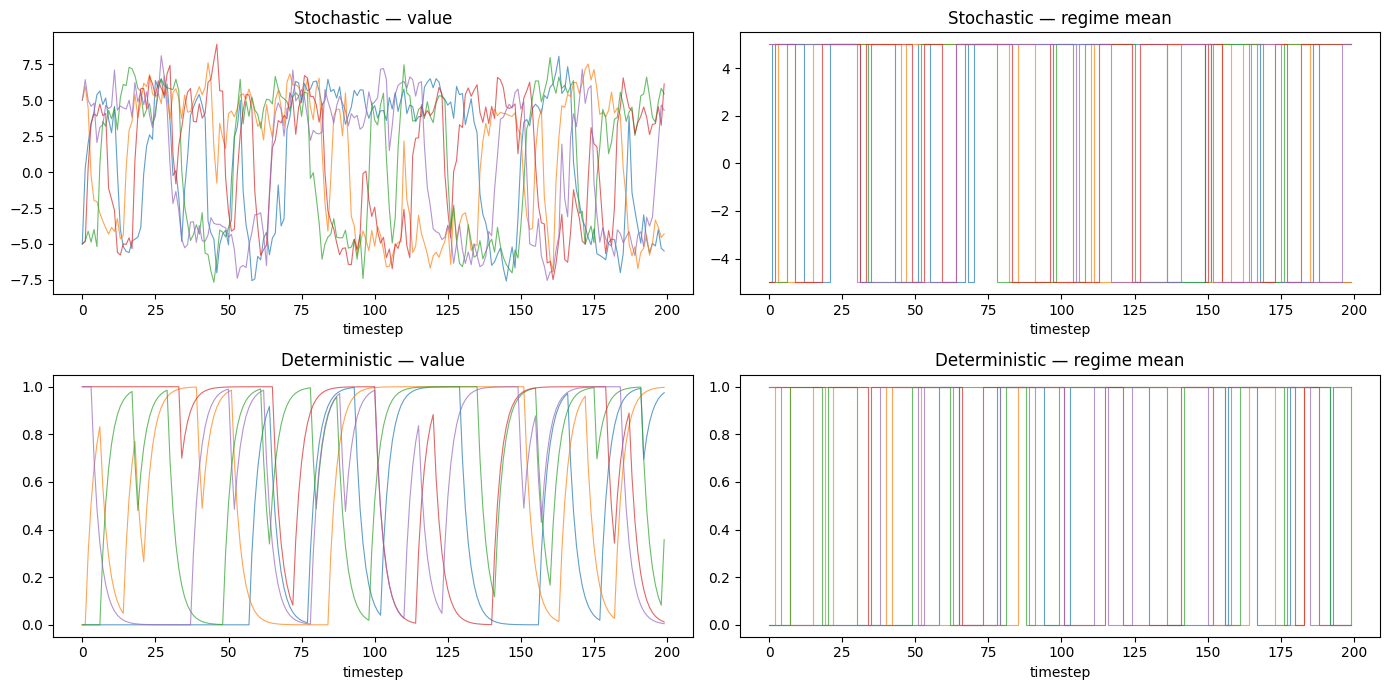

In [6]:
# Plot 5 sample paths for each process
fig, axes = plt.subplots(2, 2, figsize=(14, 7))
t = np.arange(200)

for i in range(5):
    axes[0, 0].plot(t, values[i, :, 0], lw=0.8, alpha=0.7)
    mu_path = np.array([p1.regimes[r].mu[0] for r in regimes[i, :, 0]])
    axes[0, 1].step(t, mu_path, lw=0.8, alpha=0.7, where="post")

    axes[1, 0].plot(t, values[i, :, 1], lw=0.8, alpha=0.7)
    mu_path = np.array([p2.regimes[r].mu[0] for r in regimes[i, :, 1]])
    axes[1, 1].step(t, mu_path, lw=0.8, alpha=0.7, where="post")

axes[0, 0].set_title("Stochastic — value"); axes[0, 1].set_title("Stochastic — regime mean")
axes[1, 0].set_title("Deterministic — value"); axes[1, 1].set_title("Deterministic — regime mean")
for ax in axes.flat:
    ax.set_xlabel("timestep")
fig.tight_layout()
plt.show()

### Reproducibility

Same seed produces identical output:

In [7]:
v1, r1 = model.simulate(n_paths=10, n_steps=50, seed=123)
v2, r2 = model.simulate(n_paths=10, n_steps=50, seed=123)
print(f"Values identical:  {np.array_equal(v1, v2)}")
print(f"Regimes identical: {np.array_equal(r1, r2)}")

Values identical:  True
Regimes identical: True


### Performance notes

- All uniform and normal random draws are pre-allocated in bulk before the time loop.
- Within each timestep, paths are grouped by regime to apply vectorised OU updates (no per-path Python loops).